#Assignment 1 - Hindi vocabulary test and analysis

A 200-item blinded vocabulary test whose frame is the complete vocabulary of
Premchand's *Gaban* (1931), a public-domain Hindi novel.

| | |
|---|---|
| Frame | 8,224 wordform types over 109,364 running tokens |
| Items | 160 real (40 per frequency band) + 40 pseudoword foils |
| Foils | Devanagari trigram model, ≥2 edits from a 70,936-string exclusion set |
| Scale | 2 = can define and use · 1 = partial · 0 = no knowledge |
| Round 2 | written gloss required for a sample of items scored 2 |

Because the frame is a corpus, every type carries a known token frequency — so
judgments convert directly into **text coverage** with no extrapolation.

### Setup

In [63]:
import shutil, subprocess, sys
if shutil.which("apt-get") and not any("Devanagari" in f for f in []):
    subprocess.run("apt-get install -y fonts-noto-devanagari -qq".split(),
                   capture_output=True)

import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import PercentFormatter

fm.fontManager.__init__()
have = {f.name for f in fm.fontManager.ttflist}
deva = next((c for c in ["Noto Sans Devanagari", "Noto Serif Devanagari",
                         "Nirmala UI", "FreeSerif"] if c in have), None)

PAPER, INK, MUTED, GRID = "#FDFCFA", "#14130F", "#7A7468", "#E7E2D8"
KNOWN, UNKNOWN, FOIL    = "#2F6B4F", "#A8412F", "#B08544"

BAND = ["#1C4638", "#356F58", "#71A38C", "#B9D2C6"]

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 150,
    "figure.facecolor": PAPER, "axes.facecolor": PAPER,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"] + ([deva] if deva else []),
    "font.size": 9, "text.color": INK,
    "axes.edgecolor": GRID, "axes.linewidth": .8,
    "axes.labelcolor": MUTED, "axes.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.bottom": True, "ytick.left": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": .7,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 8.5,
})

def titled(ax, title, subtitle=None):
    """Sentence-style left-aligned title with an optional muted subtitle."""
    ax.set_title(title, fontsize=10.5, fontweight="600", loc="left",
                 color=INK, pad=18 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=8.5,
                color=MUTED, va="bottom")

def label_bars(ax, bars, vals, fmt="{:.0%}", dy=.012, color=INK):
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + dy,
                fmt.format(v), ha="center", va="bottom",
                fontsize=8.5, color=color, fontweight="600")

print("Devanagari font:", deva or "NOT FOUND — Hindi labels will not render")

Devanagari font: NOT FOUND — Hindi labels will not render


### Load results

In [64]:
! gdown 1KLov9jhtSk04Zr8L4XOkUtI94LMAnoN9

Downloading...
From: https://drive.google.com/uc?id=1KLov9jhtSk04Zr8L4XOkUtI94LMAnoN9
To: /content/hindi-vocab-results.json
100% 46.4k/46.4k [00:00<00:00, 72.6MB/s]


In [65]:
PATH =  "/content/hindi-vocab-results.json"
with open(PATH, encoding="utf-8") as f:
    R = json.load(f)

df = pd.DataFrame(R["items"])
df["band"] = pd.Categorical(df["band"], ["A", "B", "C", "D", "X"], ordered=True)
frame  = R["frame"]
counts, toks, T = frame["counts"], frame["tok_by_band"], frame["tokens"]
BANDLAB = {"A": "1–500", "B": "501–1.5k", "C": "1.5k–4k", "D": "4k+"}

real, foil = df[df.is_real & ~df.disputed], df[~df.is_real & ~df.disputed]
print(f"{len(df)} items | {len(real)} real | {len(foil)} foils")
print(f"frame: {frame['types']:,} types over {frame['corpus_tokens']:,} tokens")
df.head(3)

200 items | 160 real | 40 foils
frame: 8,224 types over 109,364 tokens


,id,word,band,is_real,gaban_freq,score,score_effective,rt_ms,gloss,verified,disputed
0,1,पानदान,D,True,1,1,1,2662,None,False,False
1,2,मारूँ,D,True,1,2,1,3448,,True,False
2,3,दुकानें,D,True,1,2,2,1408,None,False,False


## 1. Validity

A vocabulary self-report means nothing without a check that the respondent can
tell real words from invented ones. The foils supply a false-alarm rate; *d′*
combines it with the hit rate into one sensitivity measure. **d′ ≥ 2.0** is the
bar; below it the run should not be reported.

Two corrections matter here and neither is applied by the in-browser scorer:

1. **The false-alarm rate should be measured *after* verification.** Foils the
   respondent retracted when asked for a definition are not false alarms.
2. **The gloss round only checked that a gloss was *given*, not that it was
   *right*.** Wrong glosses are graded by hand below — a real limitation of the
   instrument, and it belongs in the write-up rather than hidden in the number.

In [66]:
from scipy.stats import norm

v = df[df.verified].copy()
v["blank"] = v.gloss == ""


WRONG = {"मूँड़ते": 'to shave/shear — "turning" is मुड़ते',
         "नीयत":   'intention — "fixed" is नियत, a different word',
         "मोल":    'price/value, not "quantity"'}
v["wrong"]  = v.word.isin(WRONG)
v["failed"] = v.blank | v.wrong

rv, fv = v[v.is_real], v[~v.is_real]
fa_raw  = (foil.score_effective == 2).mean()
fa_post = (~fv.blank).sum() / len(foil)
hit     = (real.score_effective == 2).mean()

adj = lambda p, n: min(max(p, 1/(2*n)), 1 - 1/(2*n))
d_prime = norm.ppf(adj(hit, len(real))) - norm.ppf(adj(fa_post, len(foil)))

print(f"hit rate (real scored 2)        : {hit:.1%}")
print(f"false alarms, raw               : {fa_raw:.1%}")
print(f"false alarms, post-verification : {fa_post:.1%}  "
      f"({(~fv.blank).sum()}/{len(foil)})")
print(f"d-prime                         : {d_prime:.2f}")
print(f"median response time            : {df.rt_ms.median():.0f} ms  "
      f"({(df.rt_ms < 600).sum()} under 600 ms)")
print(f"real-word glosses               : {(~rv.failed).sum()} correct, "
      f"{rv.blank.sum()} admitted unknown, {rv.wrong.sum()} incorrect")
print()
print("VERDICT:", "PASS — reportable" if d_prime >= 2 else "FAIL — do not report")

hit rate (real scored 2)        : 91.2%
false alarms, raw               : 17.5%
false alarms, post-verification : 5.0%  (2/40)
d-prime                         : 3.00
median response time            : 1100 ms  (3 under 600 ms)
real-word glosses               : 9 correct, 2 admitted unknown, 3 incorrect

VERDICT: PASS — reportable


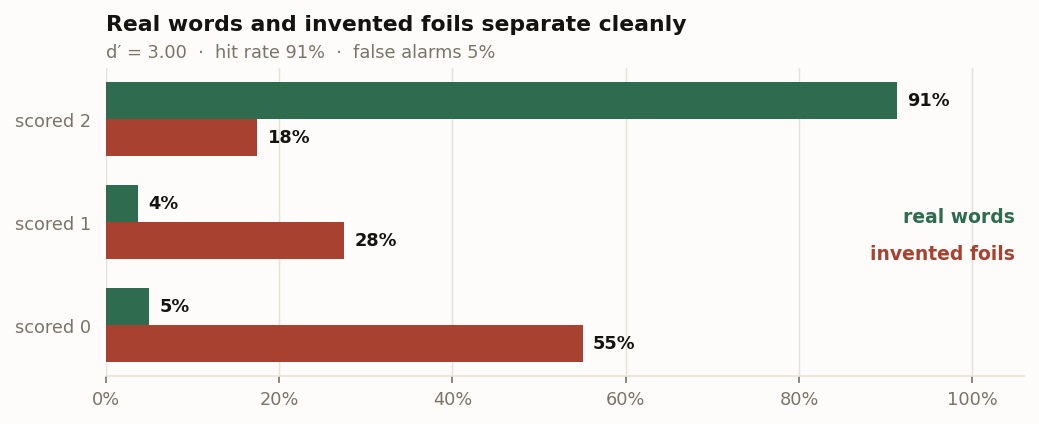

In [67]:
fig, ax = plt.subplots(figsize=(7, 2.9))
groups = ["scored 0", "scored 1", "scored 2"]
rp = [(real.score_effective == s).mean() for s in (0, 1, 2)]
fp = [(foil.score_effective == s).mean() for s in (0, 1, 2)]
y = np.arange(3); h = .36

b1 = ax.barh(y + h/2, rp, h, color=KNOWN, label="real words")
b2 = ax.barh(y - h/2, fp, h, color=UNKNOWN, label="invented foils")
for bars, vals in ((b1, rp), (b2, fp)):
    for b, val in zip(bars, vals):
        ax.text(val + .012, b.get_y() + b.get_height()/2, f"{val:.0%}",
                va="center", fontsize=8.5, color=INK, fontweight="600")

ax.set_yticks(y); ax.set_yticklabels(groups)
ax.set_xlim(0, 1.06); ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.text(.99, .5, "real words", color=KNOWN, fontweight="600", fontsize=9,
        transform=ax.transAxes, ha="right")
ax.text(.99, .38, "invented foils", color=UNKNOWN, fontweight="600", fontsize=9,
        transform=ax.transAxes, ha="right")
titled(ax, "Real words and invented foils separate cleanly",
       f"d′ = {d_prime:.2f}  ·  hit rate {hit:.0%}  ·  false alarms {fa_post:.0%}")
plt.tight_layout(); plt.show()

## 2. Knowledge by frequency band

Bands are ranked by frequency *within Gaban*, not by general Hindi frequency.
Band A is the 500 commonest types in the novel; band D is the rare tail.

In [68]:
def wilson(k, n, z=1.96):
    p = k/n; d = 1 + z*z/n
    c = (p + z*z/(2*n))/d
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n))/d
    return max(0, c-hw), min(1, c+hw)

rows = []
for b in "ABCD":
    s = real[real.band == b]; n = len(s)
    k = int((s.score_effective == 2).sum())
    p = k/n; lo, hi = wilson(k, n)
    rows.append(dict(band=b, n=n, types=counts[b], tokens=toks[b], known=p,
                     corrected=max(0, (p-fa_post)/(1-fa_post)),
                     receptive=(s.score_effective >= 1).mean(), lo=lo, hi=hi))
g = pd.DataFrame(rows).set_index("band")
g.round(3)

,n,types,tokens,known,corrected,receptive,lo,hi
band,,,,,,,,
A,40,500,79123,0.975,0.974,0.975,0.871,0.996
B,40,1000,14054,0.975,0.974,0.975,0.871,0.996
C,40,2500,9034,0.875,0.868,0.900,0.739,0.945
D,40,4224,4806,0.825,0.816,0.950,0.680,0.913


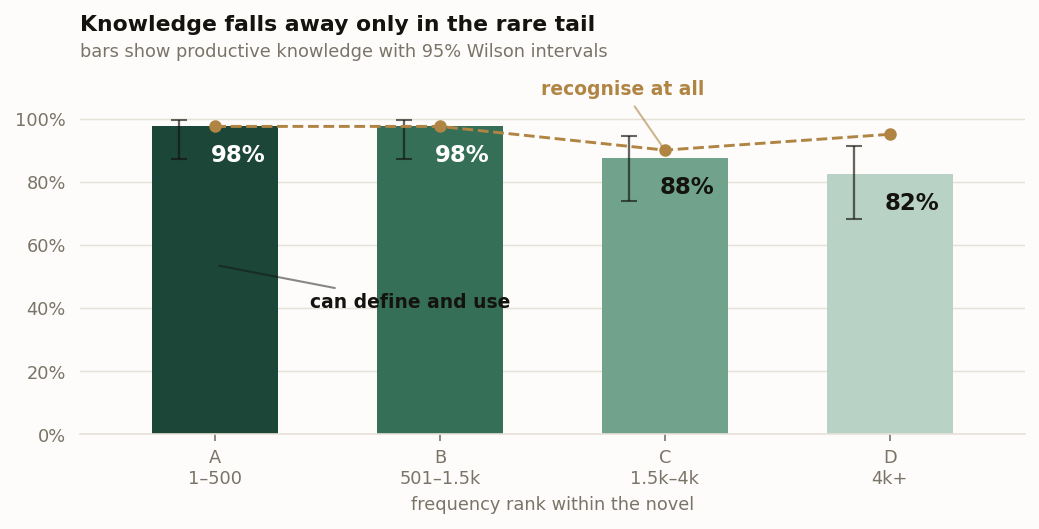

In [69]:
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(4)
bars = ax.bar(x, g.known, .56, color=BAND, edgecolor="none")
ax.errorbar(x-.16, g.known, yerr=[g.known-g.lo, g.hi-g.known], fmt="none",
            ecolor=INK, capsize=4, lw=1.1, alpha=.65)
ax.plot(x, g.receptive, "o--", color=FOIL, ms=5, lw=1.4, zorder=4)

for i, (b, val) in enumerate(zip(bars, g.known)):
    ax.text(b.get_x()+b.get_width()*.68, val-.055, f"{val:.0%}", ha="center",
            va="top", fontsize=11, fontweight="700",
            color="white" if i < 2 else INK)

ax.annotate("recognise at all", xy=(2, g.receptive.iloc[2]),
            xytext=(1.45, 1.075), color=FOIL, fontsize=9, fontweight="600",
            arrowprops=dict(arrowstyle="-", color=FOIL, lw=1, alpha=.6))
ax.annotate("can define and use", xy=(0, g.known.iloc[0]*.55),
            xytext=(.42, .40), color=INK, fontsize=9, fontweight="600",
            arrowprops=dict(arrowstyle="-", color=INK, lw=1, alpha=.5))

ax.set_xticks(x); ax.set_xticklabels([f"{b}\n{BANDLAB[b]}" for b in "ABCD"])
ax.set_xlim(-.6, 3.6)
ax.set_ylim(0, 1.16); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("frequency rank within the novel"); ax.grid(axis="x", visible=False)
titled(ax, "Knowledge falls away only in the rare tail",
       "bars show productive knowledge with 95% Wilson intervals")
plt.tight_layout(); plt.show()

## 3. Headline numbers

Two different quantities, and the gap between them is the whole point.

* **Types known** — how many distinct words: band hit rate × band size.
* **Token coverage** — how much running text is readable: weight by *tokens*.

Coverage far exceeds type knowledge because common words repeat relentlessly.

In [70]:
types_known = (g.corrected * g.types).sum()
ci_lo, ci_hi = (g.lo * g.types).sum(), (g.hi * g.types).sum()
coverage    = (g.corrected * g.tokens).sum() / T
receptive_c = (g.receptive * g.tokens).sum() / T
unknown_tok = (1 - coverage) * frame["corpus_tokens"]

print(f"types known (corrected) : {types_known:,.0f} of {frame['types']:,}"
      f"  ({types_known/frame['types']:.1%})")
print(f"95% CI                  : {ci_lo:,.0f} – {ci_hi:,.0f}")
print(f"TOKEN COVERAGE          : {coverage:.1%}   (receptive {receptive_c:.1%})")
print()
print(f"~{unknown_tok:,.0f} running words would stop you — "
      f"1 in {1/(1-coverage):.0f}, about {unknown_tok/294:.0f} per page.")

types known (corrected) : 7,077 of 8,224  (86.1%)
95% CI                  : 6,028 – 7,711
TOKEN COVERAGE          : 95.8%   (receptive 96.8%)

~4,625 running words would stop you — 1 in 24, about 16 per page.


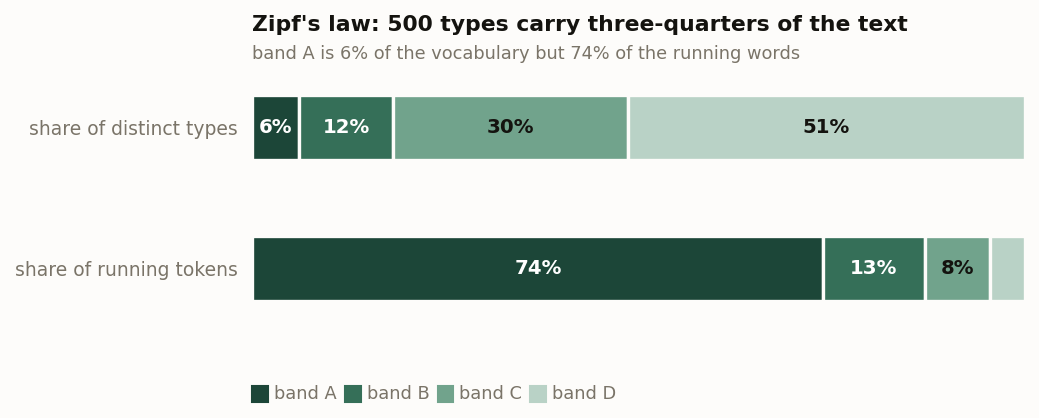

In [71]:
fig, ax = plt.subplots(figsize=(7, 2.9))
shares = {"share of running tokens": (g.tokens/g.tokens.sum()).values,
          "share of distinct types": (g.types/g.types.sum()).values}
for row, (lab, vals) in enumerate(shares.items()):
    left = 0
    for i, val in enumerate(vals):
        ax.barh(row, val, .46, left=left, color=BAND[i], edgecolor=PAPER, lw=1.6)
        if val > .045:
            ax.text(left+val/2, row, f"{val:.0%}", ha="center", va="center",
                    fontsize=9.5, fontweight="700",
                    color="white" if i < 2 else INK)
        left += val

ax.set_yticks([0, 1]); ax.set_yticklabels(list(shares), fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(-.62, 1.42); ax.set_xticks([])
ax.grid(visible=False)
for sp in ax.spines.values(): sp.set_visible(False)
for i, b in enumerate("ABCD"):
    ax.add_patch(plt.Rectangle((i*.12, -.16), .020, .055, color=BAND[i],
                               transform=ax.transAxes, clip_on=False))
    ax.text(i*.12+.028, -.133, f"band {b}", fontsize=8.5, color=MUTED,
            va="center", transform=ax.transAxes, clip_on=False)

titled(ax, "Zipf's law: 500 types carry three-quarters of the text",
       "band A is 6% of the vocabulary but 74% of the running words")
plt.tight_layout(); plt.show()

## 4. Coverage curve

If the novel's words were learned in frequency order, how fast would coverage
rise? The 95% and 98% lines are the thresholds in the reading-comprehension
literature: below roughly 95%, unassisted reading breaks down.

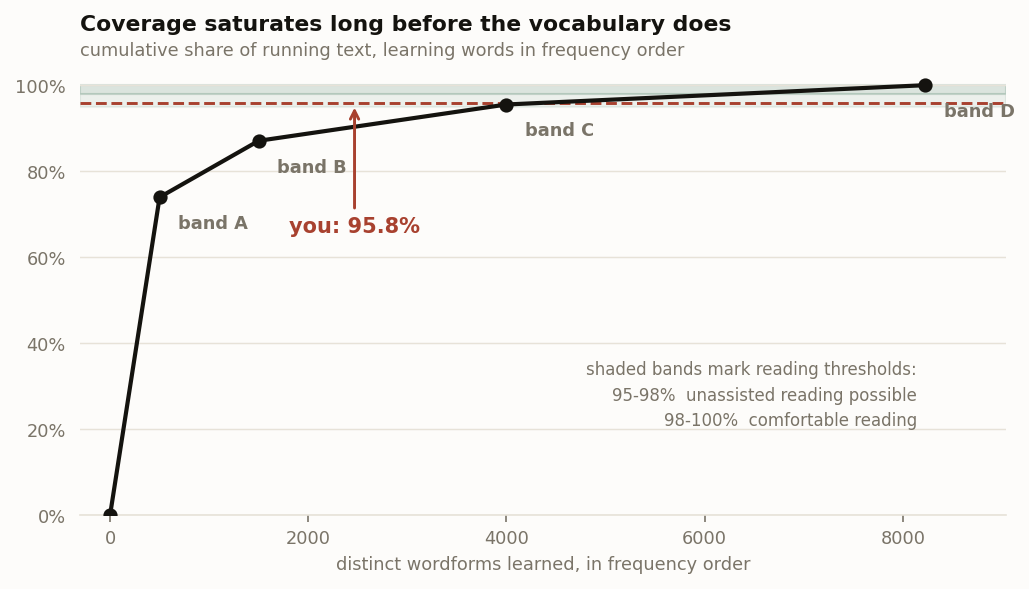

In [72]:
cum_types = np.concatenate([[0], np.cumsum(g.types.values)])
cum_cov   = np.concatenate([[0], np.cumsum(g.tokens.values)]) / T * 100

fig, ax = plt.subplots(figsize=(7, 4.0))
ax.axhspan(95, 98, color=KNOWN, alpha=.08, zorder=0)
ax.axhspan(98, 100, color=KNOWN, alpha=.16, zorder=0)
ax.plot(cum_types, cum_cov, "-", color=INK, lw=2, zorder=3)
ax.scatter(cum_types, cum_cov, s=34, color=INK, zorder=4)
ax.axhline(coverage*100, color=UNKNOWN, ls="--", lw=1.4, zorder=2)
ax.text(cum_types[-1]*.99, 36, "shaded bands mark reading thresholds:",
        ha="right", va="top", fontsize=8, color=MUTED)
ax.text(cum_types[-1]*.99, 30, "95-98%  unassisted reading possible",
        ha="right", va="top", fontsize=8, color=MUTED)
ax.text(cum_types[-1]*.99, 24, "98-100%  comfortable reading",
        ha="right", va="top", fontsize=8, color=MUTED)
ax.annotate(f"you: {coverage:.1%}", xy=(cum_types[-1]*.30, coverage*100),
            xytext=(cum_types[-1]*.30, coverage*100 - 30),
            color=UNKNOWN, fontsize=10, fontweight="700", ha="center",
            arrowprops=dict(arrowstyle="->", color=UNKNOWN, lw=1.4))
for i, b in enumerate("ABCD"):
    ax.annotate(f"band {b}", (cum_types[i+1], cum_cov[i+1]),
                textcoords="offset points", xytext=(9, -15),
                fontsize=8.5, color=MUTED, fontweight="600")

ax.set_ylim(0, 104); ax.set_xlim(-300, cum_types[-1]*1.10)
ax.set_xlabel("distinct wordforms learned, in frequency order")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.grid(axis="x", visible=False)
titled(ax, "Coverage saturates long before the vocabulary does",
       "cumulative share of running text, learning words in frequency order")
plt.tight_layout(); plt.show()

## 5. Where the gaps are

Which words are missing, and how frequency predicts knowing them.

In [73]:
miss = real[real.score_effective < 2].sort_values("gaban_freq", ascending=False)
print(f"{len(miss)} of {len(real)} real items not fully known\n")
print("most frequent unknown words:")
for r in miss.head(12).itertuples():
    print(f"   {r.word:<16} band {r.band}   {r.gaban_freq:>3}x in the novel")

14 of 160 real items not fully known

most frequent unknown words:
   अब               band A   339x in the novel
   बतला             band B     8x in the novel
   भिजवा            band C     5x in the novel
   ऊब               band C     4x in the novel
   बड़ाई             band C     3x in the novel
   ठोंककर           band C     3x in the novel
   पीती             band C     2x in the novel
   उग्र             band D     1x in the novel
   गभूमि            band D     1x in the novel
   मारूँ            band D     1x in the novel
   पानदान           band D     1x in the novel
   बैठीं            band D     1x in the novel


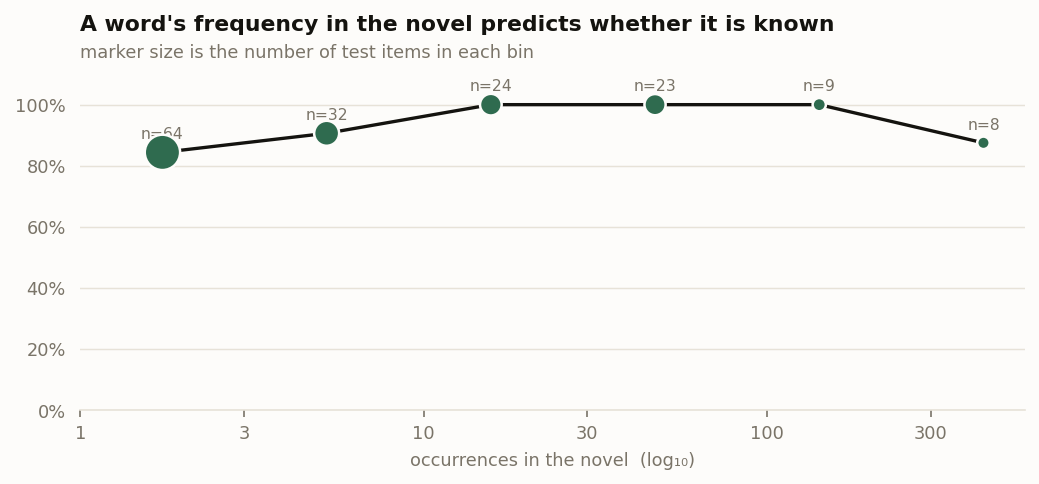

In [74]:
fig, ax = plt.subplots(figsize=(7, 3.3))
lf = np.log10(real.gaban_freq.clip(lower=1))
bins = np.linspace(0, lf.max(), 7)
mid  = (bins[:-1] + bins[1:]) / 2
prop, ns = [], []
for a, b in zip(bins[:-1], bins[1:]):
    sel = real[(lf >= a) & (lf < b)] if b < bins[-1] else real[lf >= a]
    prop.append((sel.score_effective == 2).mean() if len(sel) else np.nan)
    ns.append(len(sel))

ax.plot(mid, prop, "-", color=INK, lw=1.6, zorder=3)
ax.scatter(mid, prop, s=[max(18, n*4.5) for n in ns], color=KNOWN,
           zorder=4, edgecolor=PAPER, lw=1.2)
for m, p, n in zip(mid, prop, ns):
    if not np.isnan(p):
        ax.text(m, p + .045, f"n={n}", ha="center", fontsize=7.5, color=MUTED)
ax.set_ylim(0, 1.12); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("occurrences in the novel  (log₁₀)")
ax.set_xticks(np.log10([1, 3, 10, 30, 100, 300]))
ax.set_xticklabels(["1", "3", "10", "30", "100", "300"])
ax.grid(axis="x", visible=False)
titled(ax, "A word's frequency in the novel predicts whether it is known",
       "marker size is the number of test items in each bin")
plt.tight_layout(); plt.show()

## 6. Response times

A data-quality measure, not a vocabulary one. Implausibly fast answers suggest
the items were not being read.

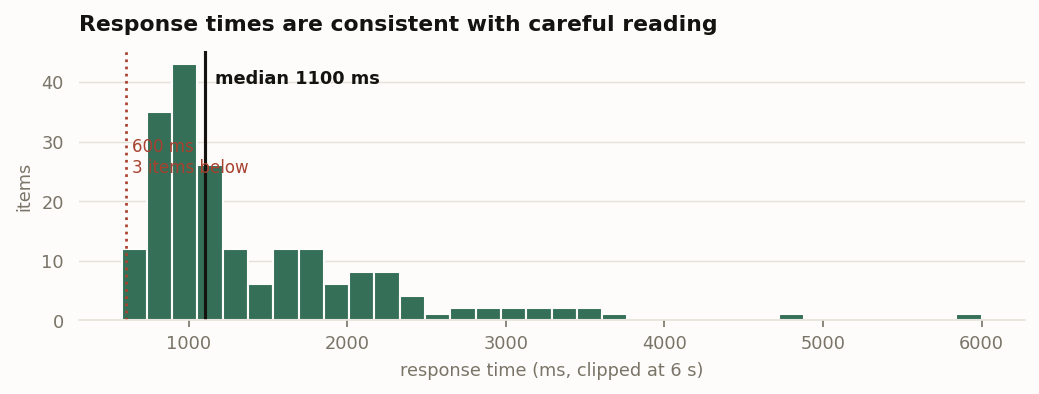

In [75]:
rt = df.dropna(subset=["rt_ms"])
fig, ax = plt.subplots(figsize=(7, 2.7))
ax.hist(rt.rt_ms.clip(upper=6000), bins=34, color=BAND[1], edgecolor=PAPER, lw=.6)
ax.axvline(rt.rt_ms.median(), color=INK, lw=1.5)
ax.text(rt.rt_ms.median()*1.06, ax.get_ylim()[1]*.88,
        f"median {rt.rt_ms.median():.0f} ms", fontsize=8.5,
        color=INK, fontweight="600")
ax.axvline(600, color=UNKNOWN, ls=":", lw=1.3)
ax.text(640, ax.get_ylim()[1]*.55,
        f"600 ms\n{(rt.rt_ms < 600).sum()} items below", fontsize=8, color=UNKNOWN)
ax.set_xlabel("response time (ms, clipped at 6 s)"); ax.set_ylabel("items")
ax.grid(axis="x", visible=False)
titled(ax, "Response times are consistent with careful reading")
plt.tight_layout(); plt.show()

## 7. Summary

In [76]:
summary = pd.DataFrame({
    "measure": ["Frame (types)", "Frame (tokens)", "Items judged", "Foils",
                "d′", "False-alarm rate (post-verification)",
                "Types known (corrected)", "95% CI", "Token coverage",
                "Receptive coverage"],
    "value": [f"{frame['types']:,}", f"{frame['corpus_tokens']:,}", len(df),
              len(foil), f"{d_prime:.2f}", f"{fa_post:.1%}",
              f"{types_known:,.0f}", f"{ci_lo:,.0f}–{ci_hi:,.0f}",
              f"{coverage:.1%}", f"{receptive_c:.1%}"]})
summary.to_csv("hindi_vocab_summary.csv", index=False)
g.round(4).to_csv("hindi_vocab_by_band.csv")
summary

,measure,value
0,Frame (types),"8,224"
1,Frame (tokens),"109,364"
2,Items judged,200
3,Foils,40
4,d′,3.00
5,False-alarm rate (post-verification),5.0%
6,Types known (corrected),"7,077"
7,95% CI,"6,028–7,711"
8,Token coverage,95.8%
9,Receptive coverage,96.8%


### Caveats for the write-up

1. **Wordforms, not lemmas.** चाहता and चाहती count separately. Hindi verbs
   license ~24 synthetic forms per infinitive, so this figure is not comparable
   to any published lemma count without dividing through.
2. **One author, one novel, 1931.** This measures coverage of *Gaban*, not of
   Hindi. Words Premchand never used are invisible to the instrument.
3. **The frame is a floor**, not a vocabulary size. A dictionary frame is needed
   for that claim.
4. **Decoding presents as knowing.** Two foils were defended with confident
   glosses — सुलज्जे as "solving" (from सुलझना) and प्रतिष्ण as "consecrated"
   (from प्रतिष्ठा). These are non-words parsed into real morphemes and assigned
   meaning: the central validity threat in any vocabulary self-report.
5. **The gloss round graded presence, not correctness.** Three glosses were wrong
   on hand review. A stricter instrument would score them.
6. **Extraction residue.** ~0.4% of tokens carry defects from the source PDF, and
   a few minor character names may survive in band D.